- 그냥 해보기
- L1 규제로 진행 (규제값 알아서 해보고) → 나중에 1~2개로 통일
- 엘라스틱 규제로 진행
- optuna 사용해서 하이퍼파라미터 최적화 해서 해보기

In [129]:
import pandas as pd
import numpy as np

_ROOT_DIR = "./../../../"

# 데이터 load

In [130]:
# 데이터 load
df = pd.read_csv(_ROOT_DIR+"./data/preprocessed/cell2cell_train.csv")
target = pd.read_csv(_ROOT_DIR+"./data/preprocessed/cell2cell_train_churn.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49776 entries, 0 to 49775
Data columns (total 65 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   MonthlyRevenue             49776 non-null  float64
 1   MonthlyMinutes             49776 non-null  float64
 2   TotalRecurringCharge       49776 non-null  float64
 3   DirectorAssistedCalls      49776 non-null  float64
 4   OverageMinutes             49776 non-null  float64
 5   RoamingCalls               49776 non-null  float64
 6   PercChangeMinutes          49776 non-null  float64
 7   PercChangeRevenues         49776 non-null  float64
 8   DroppedCalls               49776 non-null  float64
 9   BlockedCalls               49776 non-null  float64
 10  UnansweredCalls            49776 non-null  float64
 11  CustomerCareCalls          49776 non-null  float64
 12  ThreewayCalls              49776 non-null  float64
 13  ReceivedCalls              49776 non-null  flo

In [131]:
drop_cols = [
    'ThreewayCalls',
    'DroppedCalls',
    'CallForwardingCalls',
'CallWaitingCalls',
    'ActiveSubs',
    'TruckOwner',
'RVOwner',
'BuysViaMailOrder',
    'RetentionOffersAccepted',
    'NewCellphoneUser',
'NotNewCellphoneUser',
'ReferralsMadeBySubscriber',
'OwnsMotorcycle',
'AdjustmentsToCreditRating',
]
filtered_cols1 = df.filter(like='Occ_').columns
filtered_cols2 = df.filter(like='Prizm_').columns
df = df.drop(drop_cols, axis=1)
df = df.drop(filtered_cols1, axis=1)
df = df.drop(filtered_cols2, axis=1)

In [132]:
target_cols = [
'CurrentEquipmentDays',
'MonthsInService',
'MonthlyMinutes',
'PercChangeMinutes',
'PercChangeRevenues',
'TotalRecurringCharge',
'AgeHH1',
'MonthlyRevenue',
'CreditRating',
'OverageMinutes',
'HandsetRefurbished',
'IncomeGroup',
'UniqueSubs',
'HandsetPrice',
'PeakCallsInOut',
'DroppedBlockedCalls',
'RoamingCalls',
'HandsetWebCapable',
'UnansweredCalls',
'BlockedCalls',

]
df = df[target_cols]
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49776 entries, 0 to 49775
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   CurrentEquipmentDays  49776 non-null  float64
 1   MonthsInService       49776 non-null  float64
 2   MonthlyMinutes        49776 non-null  float64
 3   PercChangeMinutes     49776 non-null  float64
 4   PercChangeRevenues    49776 non-null  float64
 5   TotalRecurringCharge  49776 non-null  float64
 6   AgeHH1                49776 non-null  float64
 7   MonthlyRevenue        49776 non-null  float64
 8   CreditRating          49776 non-null  int64  
 9   OverageMinutes        49776 non-null  float64
 10  HandsetRefurbished    49776 non-null  int64  
 11  IncomeGroup           49776 non-null  float64
 12  UniqueSubs            49776 non-null  float64
 13  HandsetPrice          49776 non-null  float64
 14  PeakCallsInOut        49776 non-null  float64
 15  DroppedBlockedCalls

In [133]:
from sklearn.model_selection import train_test_split
xtrain, xtest, ytrain, ytest = train_test_split(df, target, test_size=0.2, random_state=42)
print(xtrain.shape, xtest.shape, ytrain.shape, ytest.shape)

(39820, 20) (9956, 20) (39820, 1) (9956, 1)


# 기본 학습

In [ ]:
from sklearn.tree import DecisionTreeClassifier
dtc = DecisionTreeClassifier()
dtc.fit(xtrain, ytrain)
dtc.score(xtest, ytest)


0.6202290076335878

In [135]:
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
ypred = dtc.predict(xtest)
print(accuracy_score(ypred, ytest))
print(dtc.score(xtest, ytest))

0.6202290076335878
0.6202290076335878


CurrentEquipmentDays    0.099948
PercChangeMinutes       0.098246
MonthlyMinutes          0.089919
PercChangeRevenues      0.079023
MonthlyRevenue          0.070044
UnansweredCalls         0.069691
PeakCallsInOut          0.068265
DroppedBlockedCalls     0.060208
MonthsInService         0.052946
AgeHH1                  0.046839
BlockedCalls            0.042781
TotalRecurringCharge    0.042623
OverageMinutes          0.039286
IncomeGroup             0.031785
RoamingCalls            0.030836
CreditRating            0.027298
HandsetPrice            0.019261
UniqueSubs              0.018573
HandsetRefurbished      0.007522
HandsetWebCapable       0.004905
dtype: float64


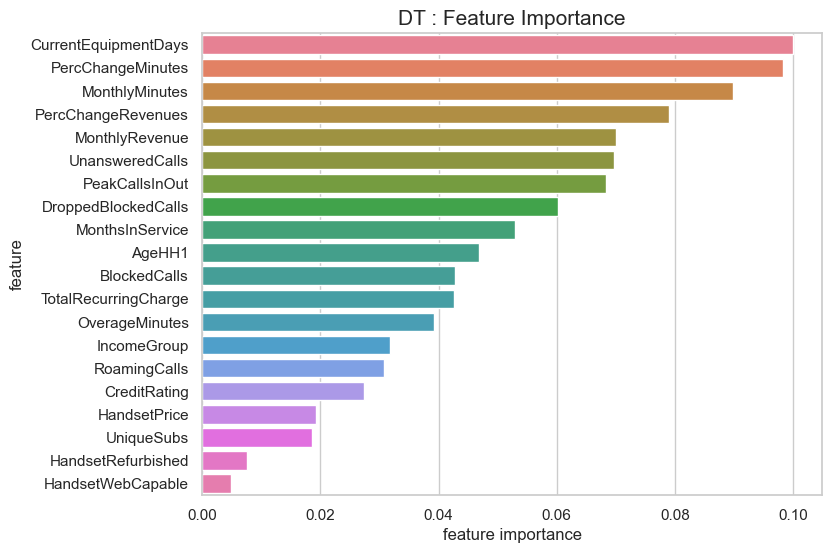

In [136]:
import seaborn as sns
from matplotlib import pyplot as plt

# 특성 중요도
fesat_impt_ser = pd.Series(dtc.feature_importances_, index=xtrain.columns)
fesat_impt_ser = fesat_impt_ser.sort_values(ascending=False)
fesat_impt_ser = fesat_impt_ser.head(20)
print(fesat_impt_ser)
plt.figure(figsize=(8,6))
sns.barplot(
    x=fesat_impt_ser,
    y=fesat_impt_ser.index,
    hue=fesat_impt_ser.index,
)
plt.xlabel('feature importance')
plt.ylabel('feature')
plt.title('DT : Feature Importance', fontsize=15)

plt.show()

In [137]:
# Confusion graph
from sklearn.metrics import classification_report, confusion_matrix

# 모델 예측 결과 확인
ypred = dtc.predict(xtest)
print(classification_report(ytest, ypred))

              precision    recall  f1-score   support

           0       0.74      0.72      0.73      7112
           1       0.35      0.38      0.36      2844

    accuracy                           0.62      9956
   macro avg       0.55      0.55      0.55      9956
weighted avg       0.63      0.62      0.62      9956



In [138]:
# Confusion Matrix
from sklearn.metrics import classification_report, confusion_matrix

# 모델 예측 결과 확인
ypred = dtc.predict(xtest)
print("              DT Classification Report")
print(classification_report(ytest, ypred))

              DT Classification Report
              precision    recall  f1-score   support

           0       0.74      0.72      0.73      7112
           1       0.35      0.38      0.36      2844

    accuracy                           0.62      9956
   macro avg       0.55      0.55      0.55      9956
weighted avg       0.63      0.62      0.62      9956



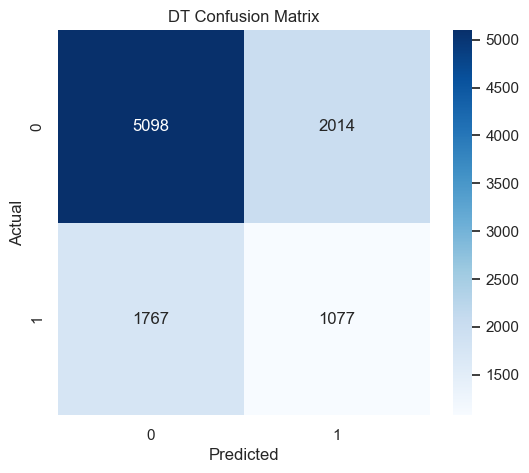

In [139]:
# Confusion Matrix 시각화2
cm = confusion_matrix(ytest, ypred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('DT Confusion Matrix')

# plt.savefig('./graphs/DT_balanced_Confusion_Matrix.png', dpi=300, bbox_inches='tight')

plt.show()

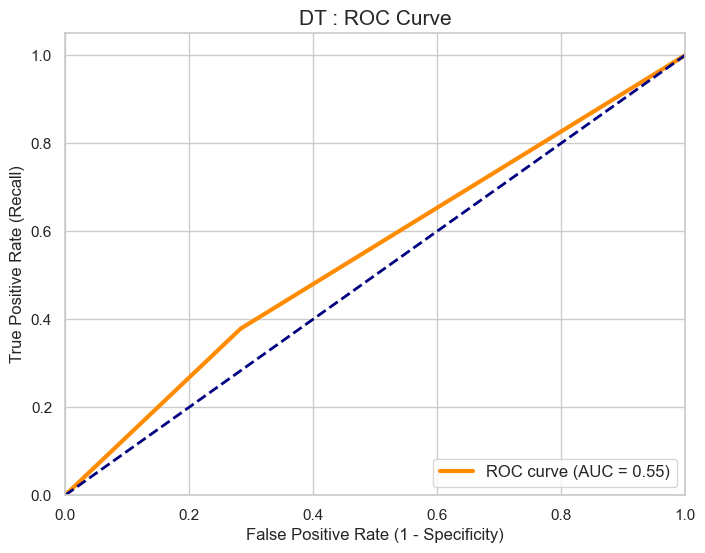

0.5477543155206865


In [140]:
# ROC 그래프
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc

# 스타일 설정
sns.set_theme(style="whitegrid")

# ROC 계산
fpr, tpr, thresholds = roc_curve(ytest, dtc.predict_proba(xtest)[:,1])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))

# ROC 곡선 그리기 (굵기 조절 및 색상 강조)
plt.plot(fpr, tpr, color='darkorange', lw=3, label=f'ROC curve (AUC = {roc_auc:.2f})')

# 대각선 점선 (Random Guess 기준선)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

# 축 범위 및 라벨 설정
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('DT : ROC Curve', fontsize=15)
plt.legend(loc="lower right", fontsize=12)

# plt.savefig('./graphs/DT_balanced_ROC_curve.png', dpi=300, bbox_inches='tight')

plt.show()

print(roc_auc)

---
---

# 최적화 적용

In [141]:
import optuna
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier
## optuna
def objective(trial):
    # 하이퍼파라미터 탐색 범위 설정
    params = {
        # 나무 최대 깊이
        "max_depth": trial.suggest_int("max_depth", 5, 30),
        # 노드를 분할하기 위한 최소 샘플 수
        "min_samples_split": trial.suggest_int("min_samples_split", 20, 500),
        # 리프 노드가 되기 위한 최소 샘플 수
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 10, 200),
        #불순도 감소 최소량
        "min_impurity_decrease": trial.suggest_float("min_impurity_decrease", 0.0, 0.01),
        # 비용 복잡도 가지치기
        "ccp_alpha" : trial.suggest_float("ccp_alpha", 1e-5, 1e-2, log=True),
        # 정보 이득 측정 방식
        "criterion": trial.suggest_categorical("criterion", ["gini", "entropy"]),
    }

    # 모델 생성 및 교차 검증
    dtc = DecisionTreeClassifier(**params, random_state=42)
    score = cross_val_score(dtc, xtrain, ytrain, cv=5, scoring='roc_auc').mean()
    return score

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=100)

# 4. 결과 확인
print("-" * 30)
print(f"최적의 파라미터: {study.best_params}")
print(f"최고 정확도: {study.best_value:.4f}")

[I 2026-02-23 14:36:13,331] A new study created in memory with name: no-name-41d42586-8769-465d-a505-2918e2d420fb
[I 2026-02-23 14:36:13,871] Trial 0 finished with value: 0.5825671899204747 and parameters: {'max_depth': 23, 'min_samples_split': 180, 'min_samples_leaf': 53, 'min_impurity_decrease': 0.003051187501268874, 'ccp_alpha': 1.4387860537555842e-05, 'criterion': 'gini'}. Best is trial 0 with value: 0.5825671899204747.
[I 2026-02-23 14:36:14,493] Trial 1 finished with value: 0.5888268813396418 and parameters: {'max_depth': 14, 'min_samples_split': 431, 'min_samples_leaf': 115, 'min_impurity_decrease': 0.004470748008871361, 'ccp_alpha': 9.110200833994871e-05, 'criterion': 'entropy'}. Best is trial 1 with value: 0.5888268813396418.
[I 2026-02-23 14:36:15,038] Trial 2 finished with value: 0.5825671899204747 and parameters: {'max_depth': 16, 'min_samples_split': 306, 'min_samples_leaf': 183, 'min_impurity_decrease': 0.004586583248934982, 'ccp_alpha': 0.0002983846522778291, 'criterion'

------------------------------
최적의 파라미터: {'max_depth': 24, 'min_samples_split': 416, 'min_samples_leaf': 110, 'min_impurity_decrease': 7.011757227115431e-05, 'ccp_alpha': 4.178371252903323e-05, 'criterion': 'gini'}
최고 정확도: 0.6438


---
---

In [142]:
from sklearn.tree import DecisionTreeClassifier
# dtc = DecisionTreeClassifier()
dtc = DecisionTreeClassifier(max_depth= 13, min_samples_split= 25, min_samples_leaf= 60, min_impurity_decrease= 0.00024039122750699286, ccp_alpha= 0.00026185454802060487, criterion= 'entropy')
dtc.fit(xtrain, ytrain)
dtc.score(xtest, ytest) 
# 최적화 전: 0.6198272398553636
# 최적화 후: 0.7166532744073926


0.7166532744073926

CurrentEquipmentDays    0.315609
MonthsInService         0.209524
MonthlyMinutes          0.102029
PercChangeMinutes       0.100831
TotalRecurringCharge    0.067180
PercChangeRevenues      0.038333
CreditRating            0.029252
HandsetRefurbished      0.027110
AgeHH1                  0.025288
MonthlyRevenue          0.022935
OverageMinutes          0.017946
HandsetWebCapable       0.013165
UniqueSubs              0.008424
DroppedBlockedCalls     0.005800
PeakCallsInOut          0.005721
RoamingCalls            0.005429
IncomeGroup             0.005425
HandsetPrice            0.000000
UnansweredCalls         0.000000
BlockedCalls            0.000000
dtype: float64


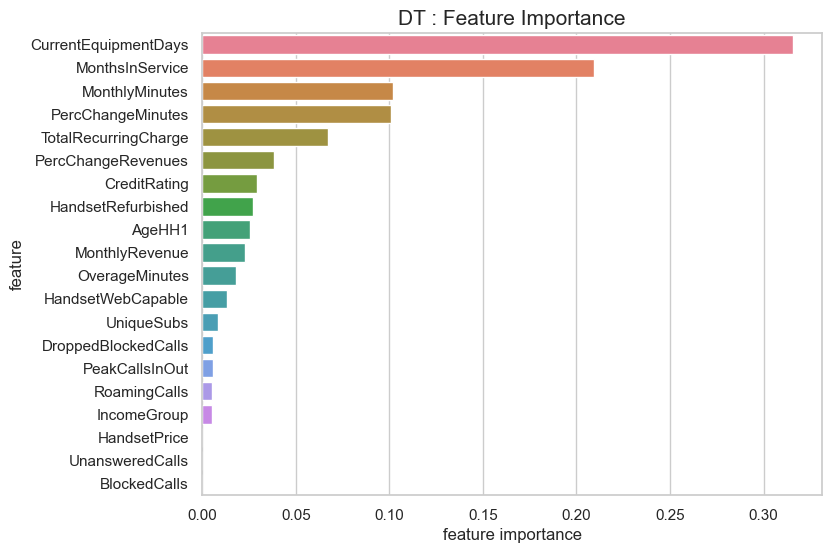

In [143]:
import seaborn as sns
from matplotlib import pyplot as plt

# 특성 중요도
fesat_impt_ser = pd.Series(dtc.feature_importances_, index=xtrain.columns)
fesat_impt_ser = fesat_impt_ser.sort_values(ascending=False)
fesat_impt_ser = fesat_impt_ser.head(20)
print(fesat_impt_ser)
plt.figure(figsize=(8,6))
sns.barplot(
    x=fesat_impt_ser,
    y=fesat_impt_ser.index,
    hue=fesat_impt_ser.index,
)
plt.xlabel('feature importance')
plt.ylabel('feature')
plt.title('DT : Feature Importance', fontsize=15)

plt.show()

In [144]:
# Confusion Matrix
from sklearn.metrics import classification_report, confusion_matrix

# 모델 예측 결과 확인
ypred = dtc.predict(xtest)
print("              DT Classification Report")
print(classification_report(ytest, ypred))

              DT Classification Report
              precision    recall  f1-score   support

           0       0.73      0.96      0.83      7112
           1       0.52      0.10      0.17      2844

    accuracy                           0.72      9956
   macro avg       0.62      0.53      0.50      9956
weighted avg       0.67      0.72      0.64      9956



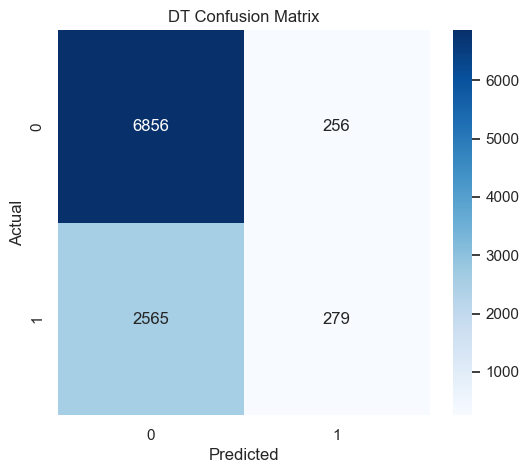

In [145]:
# Confusion Matrix 시각화2
cm = confusion_matrix(ytest, ypred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('DT Confusion Matrix')

# plt.savefig('./graphs/DT_balanced_Confusion_Matrix.png', dpi=300, bbox_inches='tight')

plt.show()

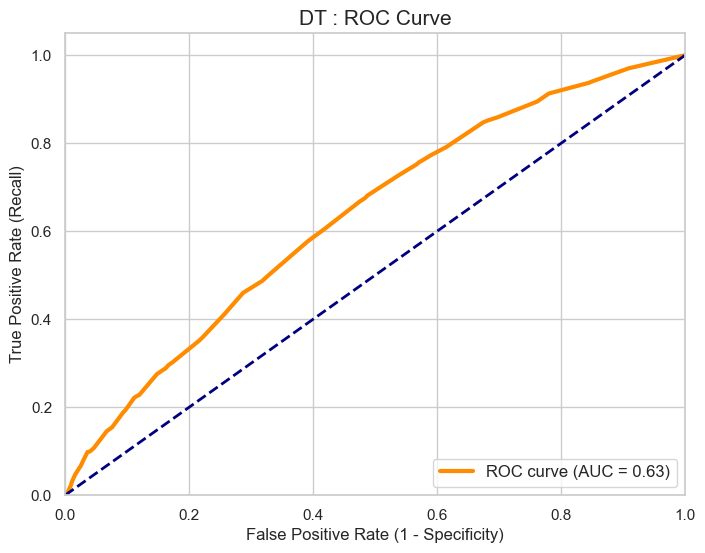

0.6326683946943341


In [146]:
# ROC 그래프
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc

# 스타일 설정
sns.set_theme(style="whitegrid")

# ROC 계산
fpr, tpr, thresholds = roc_curve(ytest, dtc.predict_proba(xtest)[:,1])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))

# ROC 곡선 그리기 (굵기 조절 및 색상 강조)
plt.plot(fpr, tpr, color='darkorange', lw=3, label=f'ROC curve (AUC = {roc_auc:.2f})')

# 대각선 점선 (Random Guess 기준선)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

# 축 범위 및 라벨 설정
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('DT : ROC Curve', fontsize=15)
plt.legend(loc="lower right", fontsize=12)

# plt.savefig('./graphs/DT_balanced_ROC_curve.png', dpi=300, bbox_inches='tight')

plt.show()

print(roc_auc)